In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv( "../DATA/Algerian_forest_fires_dataset_CLEANED.csv")


df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [13]:
import pandas as pd

class cargador_datos:

    def __init__(self, data):
        self.data = data
        self.filas = 0
        self.columnas = 0
        self.porcentaje_nulos = 0
        self.duplicados = 0

    def cargar_datos(self):
        # Obtener dimensiones del dataset
        self.filas, self.columnas = self.data.shape

        # Calcular porcentaje de nulos
        total_celdas = self.filas * self.columnas
        total_nulos = self.data.isnull().sum().sum()
        self.porcentaje_nulos = (total_nulos / total_celdas) * 100

        # Calcular registros duplicados
        self.duplicados = self.data.duplicated().sum()

        # Tipos de datos
        self.tipos_variables = self.data.dtypes

    def resumen(self):
        print("Filas:", self.filas)
        print("Columnas:", self.columnas)
        print("Porcentaje de nulos:", round(self.porcentaje_nulos, 2), "%")
        print("Duplicados:", self.duplicados)
        print("Tipos de Variables:\n", self.tipos_variables)

In [25]:
df['Classes'] = df['Classes'].str.strip()   # quita espacios
df['Classes'] = df['Classes'].str.lower()   # todo en minúscula

### En este análisis exploratorio de datos (EDA), se trabajará con el dataset Algerian Forest Fires, el cual contiene información sobre condiciones meteorológicas y ocurrencia de incendios forestales en Argelia.

#### lo que queremos es comprender la estructura de los datos, identificar patrones, detectar valores nulos o inconsistencias, y explorar relaciones entre variables que puedan influir en la ocurrencia de incendios.

### Este análisis permitirá obtener insights preliminares que podrían ser útiles para modelos predictivos o toma de decisiones.

In [31]:
## estructura del dataset 
#numero de filas y columnas 
#tipo de datos
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [32]:
## estadisticas descriptivas 

df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


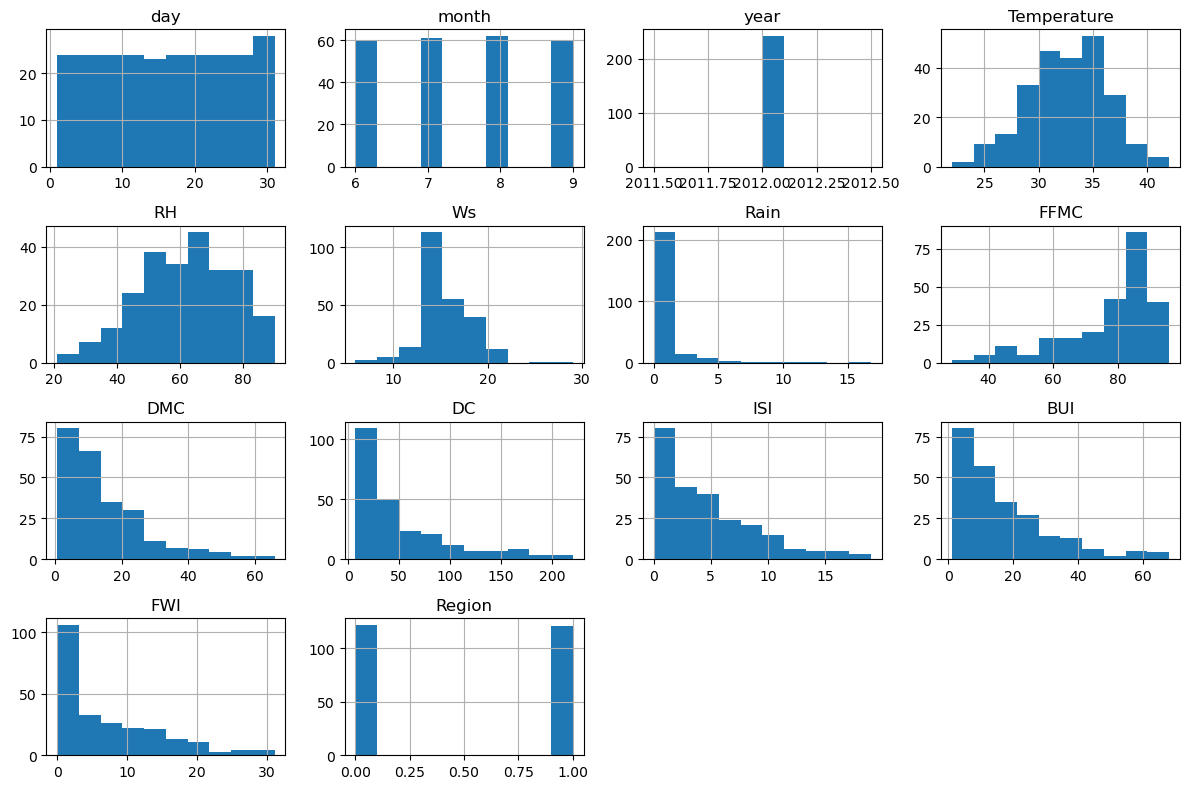

In [27]:
#Los histogramas muestran que, en general, el entorno es seco y cálido. La temperatura se mantiene en valores altos, la humedad en rangos medios 
#y casi no hay presencia de lluvia, lo que indica condiciones favorables para incendios.
#Además, las variables relacionadas con el fuego presentan en su mayoría valores bajos, pero con algunos casos altos que representan situaciones 
#más extremas.
#En conjunto, esto sugiere que el entorno suele ser estable, pero en ciertos momentos puede volverse más riesgoso para la aparición de incendios.

df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [34]:
#la cantidad de dias con incendios y no incendios x
df['Classes'].value_counts()

Classes
fire        137
not fire    106
Name: count, dtype: int64

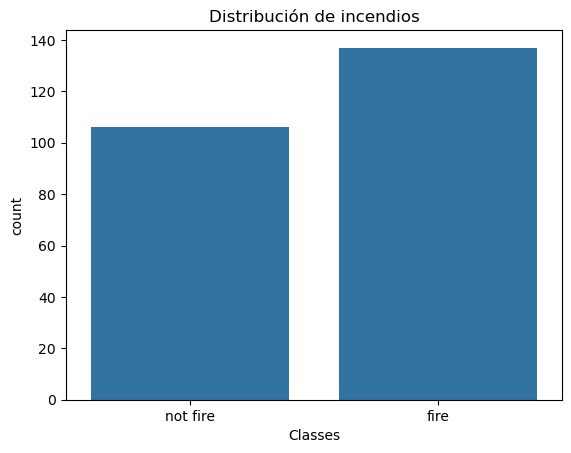

In [33]:
## Se observa una ligera mayor cantidad de casos de incendio (fire) en comparación con los días sin incendio.
sns.countplot(x='Classes', data=df)
plt.title("Distribución de incendios")
plt.show()

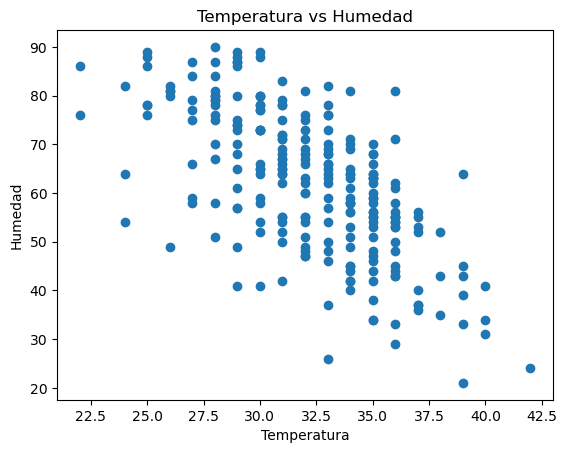

In [29]:
#Se puede ver  que la humedad relativa se concentra principalmente entre valores de 60% y 70%, indicando que estas son las condiciones 
#más frecuentes en el dataset.
#Sin embargo, a medida que la temperatura aumenta, la humedad disminuye, evidenciando una relación inversa entre ambas variables.
#Este comportamiento es relevante, ya que los niveles bajos de humedad combinados con altas 
#temperaturas generan condiciones más propicias para la ocurrencia de incendios forestales.
plt.figure()
plt.scatter(df['Temperature'], df['RH'])
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.title("Temperatura vs Humedad")
plt.show()